{'topic': '猫咪', 'poem': '## 《猫的修辞》\n\n以最轻的脚音走过书页\n用软垫封印所有声响\n尾巴，是一支蘸饱月光的笔\n在晚风里缓缓写下弧线\n\n它们擅长用呼噜声解构清晨\n将阳光揉成毛线球\n追逐着，直到线头\n缠住自己的影子\n\n这些带条纹的小小太极宗师\n推窗比开门更懂分寸\n偶尔打翻的茶杯里\n浮着一枚甲骨文般的爪印\n\n它们活在时差的夹层\n用呼噜声修补夜晚\n当被子鼓起丘陵时\n正有座神秘的国度正在召开晨会\n\n你数着它的呼吸\n发现七秒的周期\n恰好是拆解一个梦所需的\n递归次数\n\n而它蜷成句号时\n整个世界的喧哗\n在尾巴尖轻轻一点\n就化作了温柔的省略号\n\n一只猫，两只猫\n许多只猫穿越岁月的廊道\n留下细碎而锐利的目光\n在记忆的墙角\n开成倔强的猫尾草\n\n它们是未完成的叙事\n用肉垫按下的逗号\n停在某个黄昏与黎明的交界\n等一个耐心的读者\n将毛茸茸的句子读成春天\n\n直到深夜，某盏未熄的灯下\n忽然有温热的重量\n跃上膝头，眯起眼\n将整个白昼的疲惫\n卷成休眠的磁带\n\n它教会我们\n如何收拢锋利的光阴\n如何在黑暗中\n找到最柔软的落脚点\n并在某个安静的瞬间\n成为自己故事的句号', 'ci_poem': '《卜算子·咏狸奴》\n憨态卧花阴，软爪扑流萤。\n醉眼懵腾觑蝶影，忽跃琉璃镜。\n漫理雪毛轻，自占云台静。\n夜半巡檐捕月声，一尾摇星柄。\n\n赏析：这首作品以猫为主题，通过“卧花阴”“扑流萤”等生动场景展现猫咪的活泼与悠然。下阕“漫理雪毛”“巡檐捕月”等句，既刻画其优雅仪态，又暗含捕鼠本能的野性。尾句“一尾摇星柄”以星喻猫尾，将月夜巡游的猫咪与星空相融，赋予传统意象灵动机趣的新解。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '一只猫对主人说：“我其实会说话。”主人震惊：“那你平时为什么装哑？”猫翻了个白眼：“因为一旦让你知道我会说话，你就会让我接电话、回邮件、还要负责关闹钟。现在这样多好，我只需要负责打翻杯子、睡觉和当个高冷的美人。”', 'ci_poem': '《南歌子·狸奴》\n日暖临窗懒，风轻抱尾眠。\n琉璃眸子转清圆，偶扑流苏、玉爪弄云团。\n月下巡檐急，花间捕影翩。\n夜阑声寂小星悬，悄立屏风、暗逐绣球欢。\n\

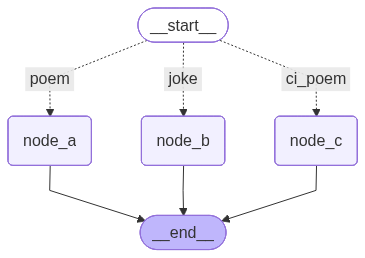

In [1]:
from typing import TypedDict,Literal,Sequence
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem:str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([f"写一首关于{state['topic']}主题的词"]).content
    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["poem","joke","ci_poem"]]:
    if "诗" in state["content_type"]:
        return ["poem","ci_poem"]
    else:
        return ["joke","ci_poem"]


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)

builder.add_conditional_edges(
    START,
    my_route,
    path_map={
        "poem": "node_a",
        "joke": "node_b",
        "ci_poem": "node_c",
    }
)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)
builder.add_edge("node_c",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
print(joke_res)

from IPython.display import display
display(graph)


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from loguru import logger

from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def audit_node(state: OverAllState) -> OverAllState:
    logger.info(f"任务节点全部执行完毕，诗 {'已生成' if state['poem'] else '未生成'}，笑话 {'已生成' if state['joke'] else '未生成'}")

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("audit_node", audit_node, defer=True)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge(START, "audit_node")
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("audit_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "布偶狗"})
print(res)

from IPython.display import display

display(graph)